# Модель для предсказания массы морских черепах



- Придумайте тетрадке заголовок, который хорошо описывает решаемую задачу.
- Кратко, но понятно опишите решаемую задачу.

## Задачи:
 * Разработать надёжную модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах
 

## Постановка задачи машинного обучения

- Опишите, какую задачу нужно решить: регрессии или классификации.
- Выберите поле, которое станет целевой переменной.
- Назовите метрики качества модели, которые планируете использовать.
- Опишите критерии успешности проекта с опорой на метрики.

* Необходимо решить задачу линейной регрессии
* Целевой переменной является `weight` - масса черепахи, кг.
* Для выполнения задачи требуется использовать модели `LinearRegression`, `Lasso`, `Ridge`, `SGDRegressor`
* Основной метрикой качества, как следует из задания, будет являться `MAE`


# Основные требования к продукту
* Модель должна быть линейной, чтобы полученные коэффициенты в дальнейшем использовать для простой функции прогнозирования.
* Для целевой популяции зелёных морских черепах массой от 50 до 150 килограмм приемлемая метрика `MAE` в случае взрослых особей — не более 5 кг. Опирайтесь на этот критерий при отборе модели.
* Модель должна уметь предсказывать массу черепах разного возраста и, соответственно, размера. Выходит, значимая ошибка модели зависит от масштаба признаков, поэтому необходимо оценить модель и метрикой, демонстрирующей среднюю ошибку в относительном значении, — `MAPE`.
* Модель должна достичь высокого значения `R²`, то есть объяснять большую часть вариативности массы. Значение метрики должно быть не меньше 0.97 на валидационной и тестовой выборках для лучшей модели, рекомендуемой к внедрению.
* В тестовой выборке должно быть 20% от предоставленных в датасете наблюдений.
* Необходимо обеспечить воспроизводимость экспериментов, фиксируя везде, где это необходимо, начальное состояние генераторов случайных чисел `random_stat`.
* По результатам моделирования необходимо написать функцию предсказания массы черепахи по её признакам, используя формулу линейной регрессии.

## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [1]:
! pip install phik -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
plt.figure(figsize=(20,15))
import seaborn as sns
from phik import phik_matrix
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

<Figure size 1440x1080 with 0 Axes>

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [2]:
df = pd.read_csv('/datasets/turtles.csv',sep='\t', decimal=',')
print(df.info())
print(df.columns)
print(f'Количество дубликатов по всем столбцам: {df.duplicated().sum()}')
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [3]:
#Выводим ункальные значение
for column in df.columns:
    print(f'Уникальные значения в {column}:')
    print(df[column].unique())
    print(f'Количество уникальных значений в {column}:')
    print(df[column].nunique())

Уникальные значения в id:
[20438 19034 24689 ... 23435 21143 24105]
Количество уникальных значений в id:
7842
Уникальные значения в binomial_name:
['Caretta caretta' 'Lepidochelys olivacea' 'LEPIDOCHELYS OLIVACEA'
 'Lepidochelys Olivacea' 'lepidochelys olivacea' 'Chelonia mydas'
 'ERETMOCHELYS IMBRICATA' 'Eretmochelys imbricata' 'Dermochelys coriacea'
 'caretta caretta' 'CARETTA CARETTA' 'chelonia mydas' 'Chelonia Mydas'
 'CHELONIA MYDAS' 'Dermochelys Coriacea' 'eretmochelys imbricata' nan
 'Caretta Caretta' 'lepidochelys kempii' 'Lepidochelys kempii'
 'Eretmochelys Imbricata' 'dermochelys coriacea' 'Lepidochelys Kempii'
 'DERMOCHELYS CORIACEA']
Количество уникальных значений в binomial_name:
23
Уникальные значения в registration number:
['d89af72662f49ece4d09dec75a8b0166' '1579c64777de4db1c16e8b7b0d19c45e'
 'bfcec01187569615087e4d777c44985a' ... '7d65c2b1a5750da62fb459cf4020887d'
 '6d4abbb15e0284aeeff2b36ce501ea16' '63f8cd4da22a5f8e43d68cbb22d5c784']
Количество уникальных значений в r

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

In [4]:
# Удалим из данных столбцы 'id', 'registration number', 'measure_count','measure_count', 'timestamp' так как они не несут признаков необходимых для обучения моделей
# Столбец 'shell_crack' вынужден удалить из-за количества пропусков, в нем 560 значений из 2325
# Столбец 'binomial_name' так же удаляем поскольку в выборке остался только один конкретный вид
# Удаляем nan из столбца 'weight' так как он является целевым и пропусков нем было 2
df_chelonia_mydas = df[df['binomial_name']=='Chelonia mydas'][['shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'weight']]
count_row=df_chelonia_mydas.shape[0]
print(f'Количество строк осталось после фильтрации по имени: {count_row}')
print(f'Количество дубликатов по всем столбцам: {df_chelonia_mydas.duplicated().sum()}')
print(df_chelonia_mydas.info())
df_chelonia_mydas=df_chelonia_mydas.drop_duplicates()
df_chelonia_mydas=df_chelonia_mydas.dropna(subset=['weight'])
count_row1=df_chelonia_mydas.shape[0]
print(f'Количество строк осталось после удаления дубликатов: {count_row1}')
print(f'Удалено дубликатов:{round(((count_row-count_row1)*100/count_row), 2)}%')

Количество строк осталось после фильтрации по имени: 2325
Количество дубликатов по всем столбцам: 295
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2325 entries, 8 to 8859
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2294 non-null   float64
 1   shell_width       2325 non-null   int64  
 2   head_length       2292 non-null   float64
 3   head_width        2292 non-null   float64
 4   flipper_length_1  2325 non-null   int64  
 5   flipper_width_1   2325 non-null   int64  
 6   flipper_length_2  2325 non-null   int64  
 7   flipper_width_2   2325 non-null   int64  
 8   flipper_length_3  2301 non-null   float64
 9   flipper_width_3   2301 non-null   float64
 10  flipper_length_4  2301 non-null   float64
 11  flipper_width_4   2301 non-null   float64
 12  circle_count      2325 non-null   int64  
 13  weight            2322 non-null   float64
dtypes: float64(8), int64(6)
memory usa

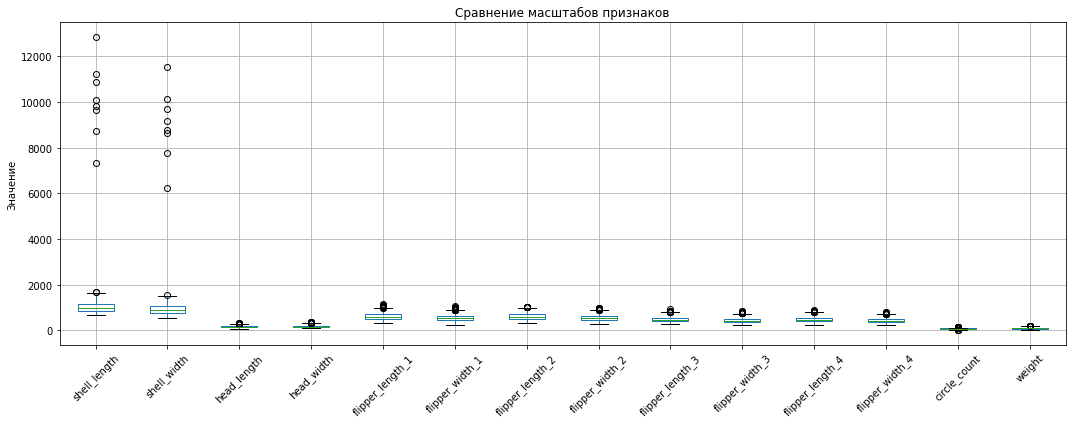

In [5]:
def box_plot(df):
# Устанавливаем размер фигуры (ширина 10, высота 6)
    plt.figure(figsize=(15, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
    df.boxplot(column=['shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'weight'])

# Заголовок графика
    plt.title('Сравнение масштабов признаков')

# Подпись оси Y
    plt.ylabel('Значение')

# Поворот подписей по оси X (угол можно изменить)
    plt.xticks(rotation=45)  # или rotation=90 для вертикального расположения

# Автоматическая корректировка отступов, чтобы подписи не обрезались
    plt.tight_layout()

# Показываем график
    return plt.show()
box_plot(df_chelonia_mydas)

### Поправил гистограммы

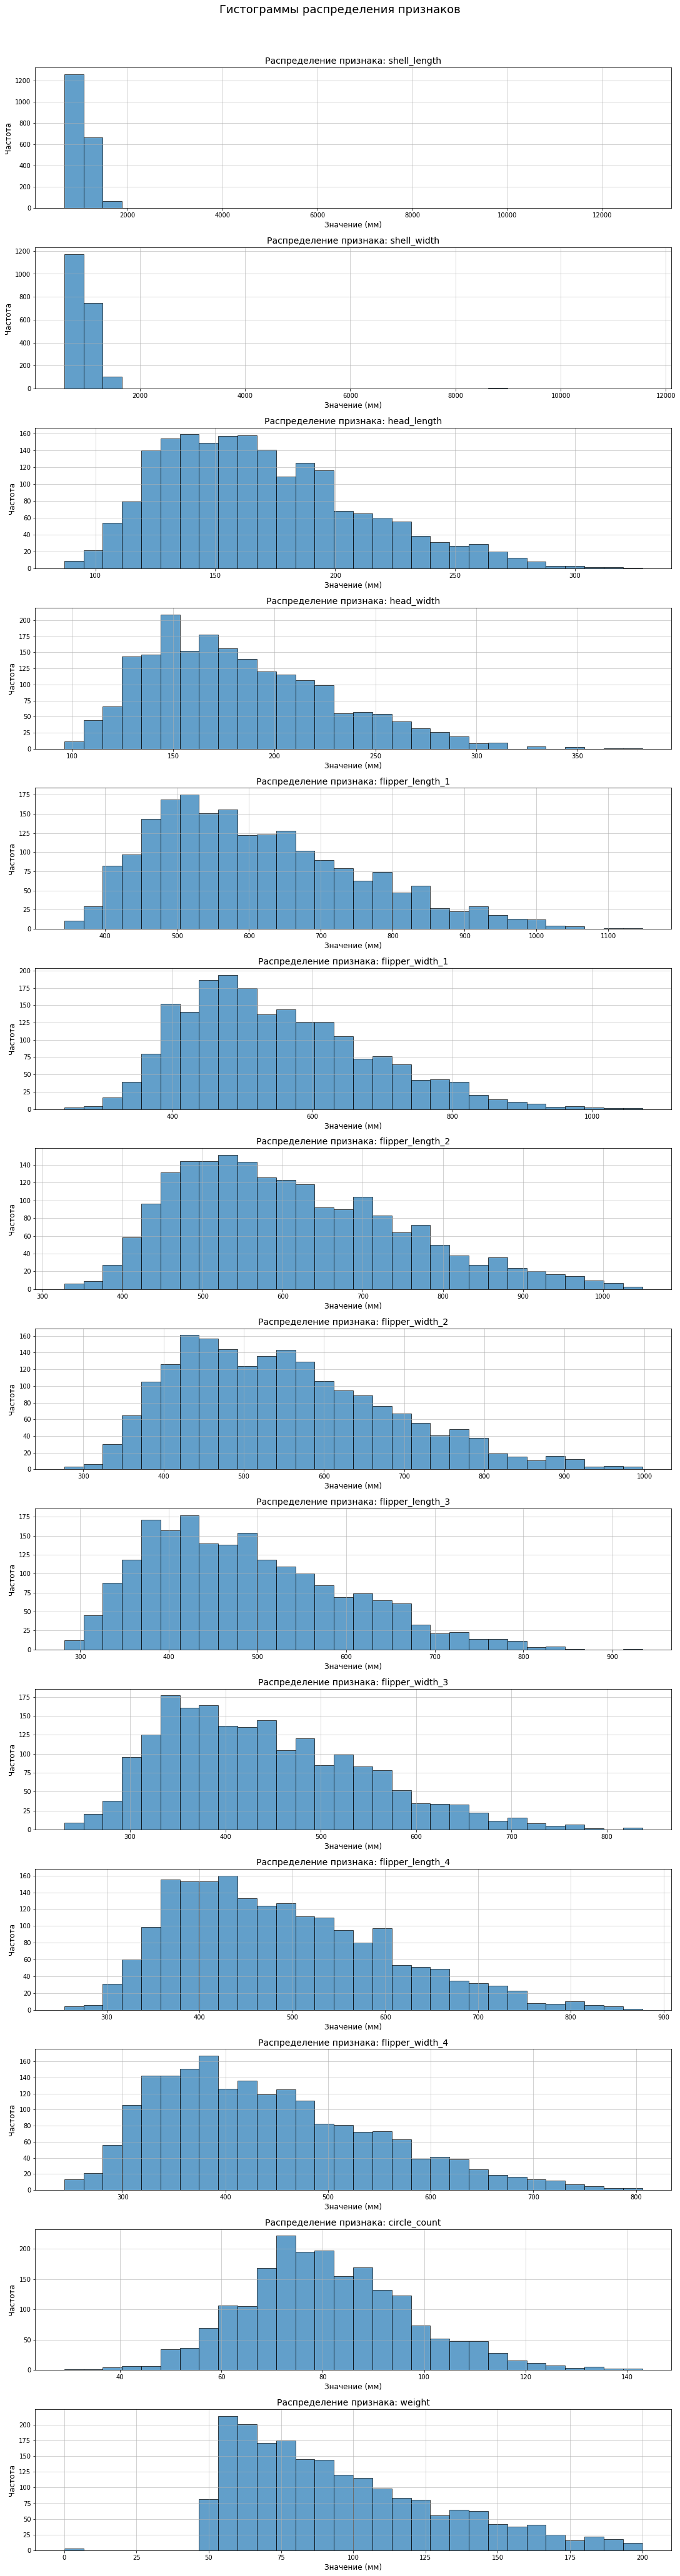

In [6]:
def full_plot_bigger(df):
    # Получаем список колонок
    columns = df.columns
    n = len(columns)
    
    # Создаем фигуру с нужным количеством подграфиков
    fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), constrained_layout=True)

    # Создаем гистограммы для каждого признака
    for i, column in enumerate(columns):
        axes[i].hist(df[column], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_xlabel('Значение (мм)', fontsize=12)
        axes[i].set_ylabel('Частота', fontsize=12)
        axes[i].set_title(f'Распределение признака: {column}', fontsize=14)
        axes[i].grid(True, alpha=0.7)
    
    plt.suptitle('Гистограммы распределения признаков', fontsize=18, y=1.02)
    return fig, axes

fig, axes = full_plot_bigger(df_chelonia_mydas)
plt.show()

### Тепловая карта корреляции phik

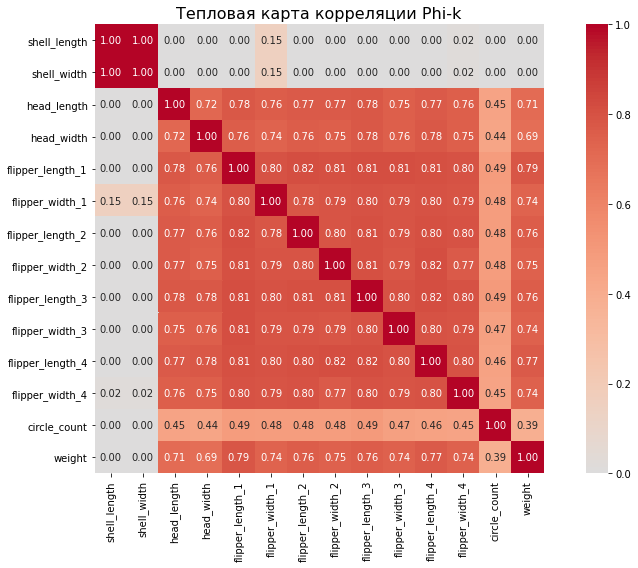

In [ ]:
correlation_matrix = df_chelonia_mydas.phik_matrix(interval_cols=df_chelonia_mydas.select_dtypes(include=['float64', 'int64']).columns.tolist())
# Создаем тепловую карту с count_order
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=True)    # Квадратные ячейки

plt.title('Тепловая карта корреляции Phi-k', fontsize=16)
plt.tight_layout()
plt.show()

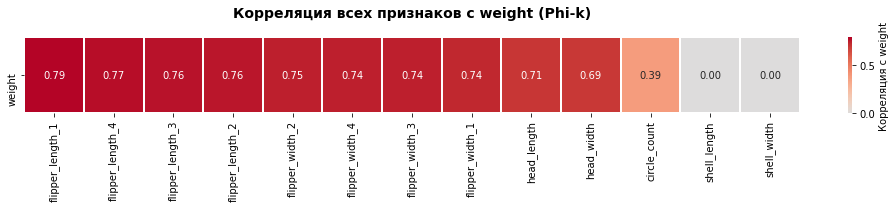

In [9]:
# Извлекаем корреляцию с weight и удаляем сам weight из списка
weight_corr = correlation_matrix['weight'].drop('weight')

# Сортируем по убыванию корреляции
weight_corr_sorted = weight_corr.sort_values(ascending=False)
# Создаем DataFrame с корреляциями с weight
weight_corr_df = pd.DataFrame(weight_corr_sorted).T  # Транспонируем в одну строку

# Создаем тепловую карту
plt.figure(figsize=(14, 3))
sns.heatmap(weight_corr_df, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=False,   # Не обязательно квадратные ячейки
            cbar_kws={'label': 'Корреляция с weight'},
            linewidths=1,   # Границы между ячейками
            linecolor='white')

plt.title('Корреляция всех признаков с weight (Phi-k)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Столбец 'shell_length': 8 значений разделено на 10
Столбец 'shell_width': 8 значений разделено на 10


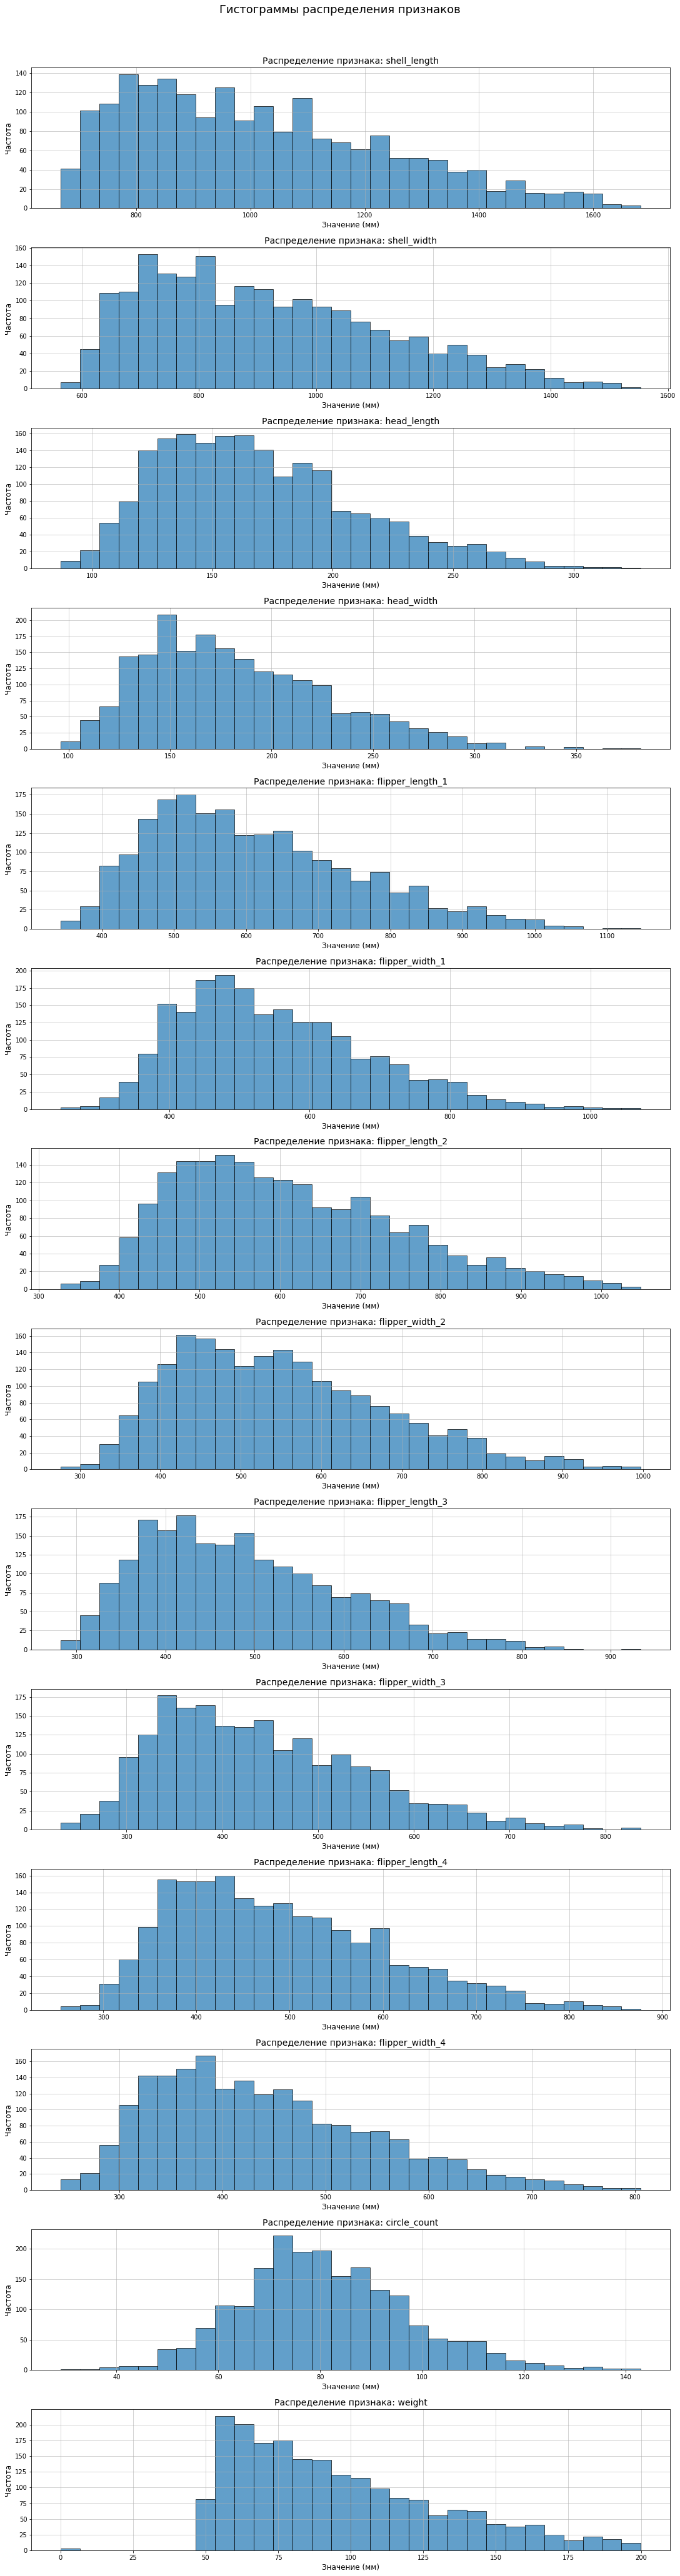

In [11]:
def correct_training_data_simple(df, columns_to_correct=['shell_length', 'shell_width'], threshold=4000):

    X_corrected = df.copy()
    
    # Проверяем, что указанные столбцы существуют в DataFrame
    existing_columns = [col for col in columns_to_correct if col in X_corrected.columns]
    
    # Применяем коррекцию только к указанным столбцам
    for column in existing_columns:
        mask = X_corrected[column] > threshold
        if mask.any():
            count = mask.sum()
            X_corrected.loc[mask, column] = X_corrected.loc[mask, column] / 10
            print(f"Столбец '{column}': {count} значений разделено на 10")
    
    return X_corrected

df_chelonia_mydas = correct_training_data_simple(df_chelonia_mydas, columns_to_correct=['shell_length', 'shell_width'])
#full_plot(df_chelonia_mydas)

fig, axes = full_plot_bigger(df_chelonia_mydas)
plt.show()

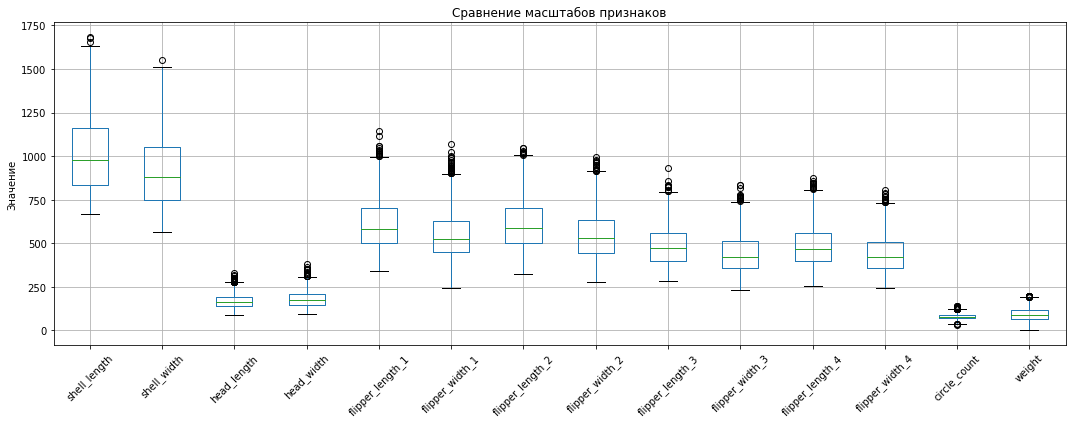

In [12]:
box_plot(df_chelonia_mydas)

In [13]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    #Сортировка по количеству пропусков
    missing_stats = missing_stats.sort_values('Кол-во пропусков', ascending=False)
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df_chelonia_mydas)

,Кол-во пропусков,Доля пропусков
head_length,29,0.0143
head_width,29,0.0143
shell_length,25,0.0123
flipper_length_3,22,0.0108
flipper_width_3,22,0.0108
flipper_length_4,22,0.0108
flipper_width_4,22,0.0108


1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

In [14]:
train_df, test_df = train_test_split (df_chelonia_mydas, test_size=0.2, shuffle = True, random_state=42)
train_df, val_df = train_test_split (train_df, test_size=0.25, shuffle = True, random_state=42)

In [15]:
display(f'Размерность train_df: {train_df.shape}')
display(f'Размерность val_df: {val_df.shape}')
display(f'Размерность test_df: {test_df.shape}')

'Размерность train_df: (1216, 14)'

'Размерность val_df: (406, 14)'

'Размерность test_df: (406, 14)'

In [16]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1216 entries, 3914 to 5439
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      1204 non-null   float64
 1   shell_width       1216 non-null   float64
 2   head_length       1199 non-null   float64
 3   head_width        1199 non-null   float64
 4   flipper_length_1  1216 non-null   int64  
 5   flipper_width_1   1216 non-null   int64  
 6   flipper_length_2  1216 non-null   int64  
 7   flipper_width_2   1216 non-null   int64  
 8   flipper_length_3  1200 non-null   float64
 9   flipper_width_3   1200 non-null   float64
 10  flipper_length_4  1200 non-null   float64
 11  flipper_width_4   1200 non-null   float64
 12  circle_count      1216 non-null   int64  
 13  weight            1216 non-null   float64
dtypes: float64(9), int64(5)
memory usage: 142.5 KB
None


In [17]:
def fill_missing_by_weight(df):
    # Создаем категории по весу
    df['shell_weight_category'] = pd.qcut(
        df['weight'], 
        q=4, 
        labels=['small', 'medium', 'large', 'xlarge'],
        duplicates='drop'
    )
    
    # Список столбцов для заполнения
    cols_to_impute = ['head_length', 'head_width', 'shell_length',
                      'flipper_length_3', 'flipper_width_3',
                      'flipper_length_4', 'flipper_width_4', 'weight']
    
    # Заполняем пропуски медианой по категории
    for col in cols_to_impute:
        if col in df.columns:  # Проверяем, что столбец существует
            df[col] = df.groupby('shell_weight_category')[col].transform(
                lambda x: x.fillna(x.median())
            )
    
    # Удаляем вспомогательный столбец
    df = df.drop(columns=['shell_weight_category'])
    
    return df
df_train_fill = fill_missing_by_weight(train_df)
df_val_fill = fill_missing_by_weight(val_df)
df_test_fill = fill_missing_by_weight(test_df)
print('Проверим наличие пропусков:')
print(f'Пропуски в учебных данных: {show_missing_stats(df_train_fill)}')
print(f'Пропуски в валидационных данных: {show_missing_stats(df_val_fill)}')
print(f'Пропуски в тестовых данных: {show_missing_stats(df_test_fill)}')

Проверим наличие пропусков:
Пропуски в учебных данных: Пропусков в данных нет
Пропуски в валидационных данных: Пропусков в данных нет
Пропуски в тестовых данных: Пропусков в данных нет


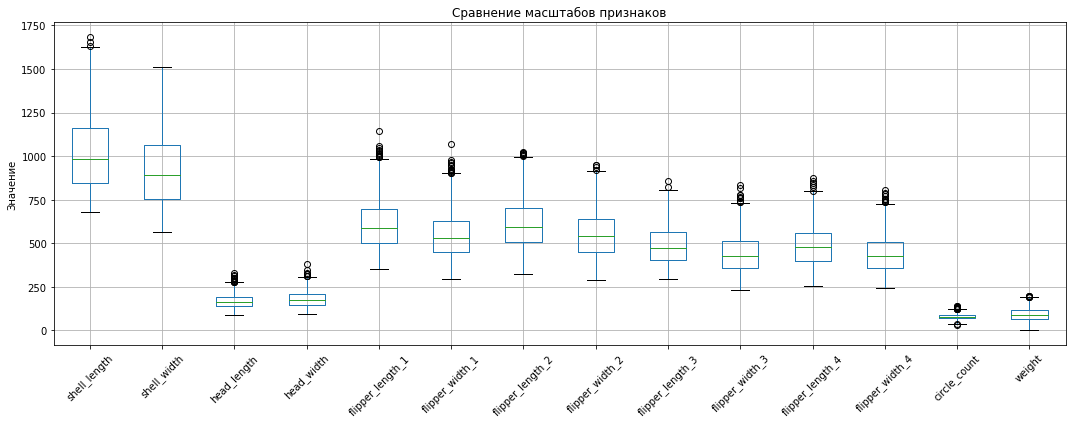

In [ ]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(15, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
df_train_fill.boxplot(column=['shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'weight'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Поворот подписей по оси X
plt.xticks(rotation=45)  

# Автоматическая корректировка отступов, чтобы подписи не обрезались
plt.tight_layout()

# Показываем график
plt.show() 

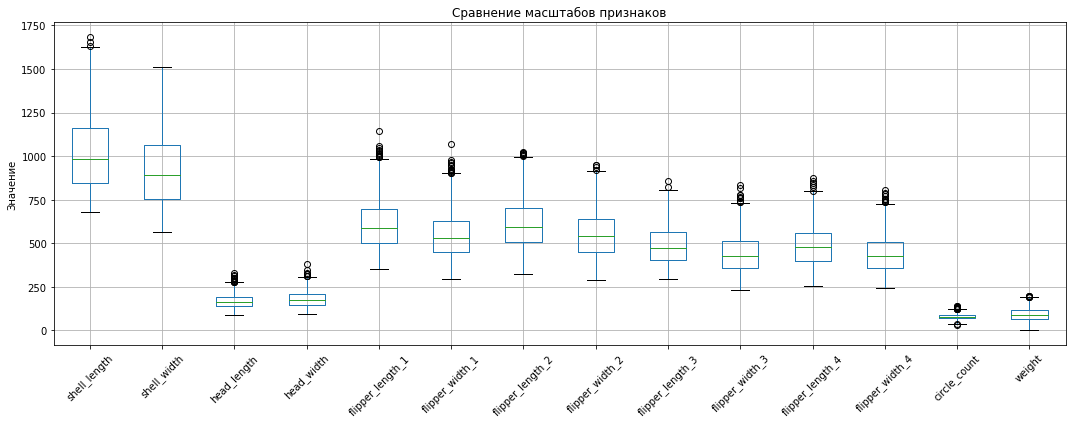

In [ ]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(15, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
df_train_fill.boxplot(column=['shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'weight'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Поворот подписей по оси X
plt.xticks(rotation=45)

# Автоматическая корректировка отступов, чтобы подписи не обрезались
plt.tight_layout()


# Показываем график
plt.show() 

In [ ]:
# Разделяем на признаки и целевую переменную
X_train = df_train_fill.drop(columns=['weight'])  # исключаем целевую переменную
y_train = df_train_fill['weight']

X_val = df_val_fill.drop(columns=['weight'])
y_val = df_val_fill['weight']

X_test = df_test_fill.drop(columns=['weight'])
y_test = df_test_fill['weight']

In [21]:
# Создаем функции для масштабирования
def minmax(X_train, X_val, X_test):
# Вычисляем min и max на X_train
    min_train = X_train.min()
    max_train = X_train.max()

# Мин-макс масштабирование для train
    X_train_minmax = (X_train - min_train) / (max_train - min_train)
    X_val_minmax = (X_val - min_train) / (max_train - min_train)
    X_test_minmax = (X_test - min_train) / (max_train - min_train)
    return X_train_minmax, X_val_minmax, X_test_minmax

def standarting(X_train, X_val, X_test):
# Вычисляем mean и std на X_train
    mean_train = X_train.mean()
    std_train = X_train.std()    
    
# Стандартизируем
    X_train_scaled = (X_train - mean_train) / std_train
    X_val_scaled = (X_val - mean_train) / std_train
    X_test_scaled = (X_test - mean_train) / std_train
    return X_train_scaled, X_val_scaled, X_test_scaled

#Вызываем функции
X_train_minmax, X_val_minmax, X_test_minmax= minmax(X_train, X_val, X_test)
X_train_scaled, X_val_scaled, X_test_scaled= standarting(X_train, X_val, X_test)

'Гистограммы X_train после min-max'

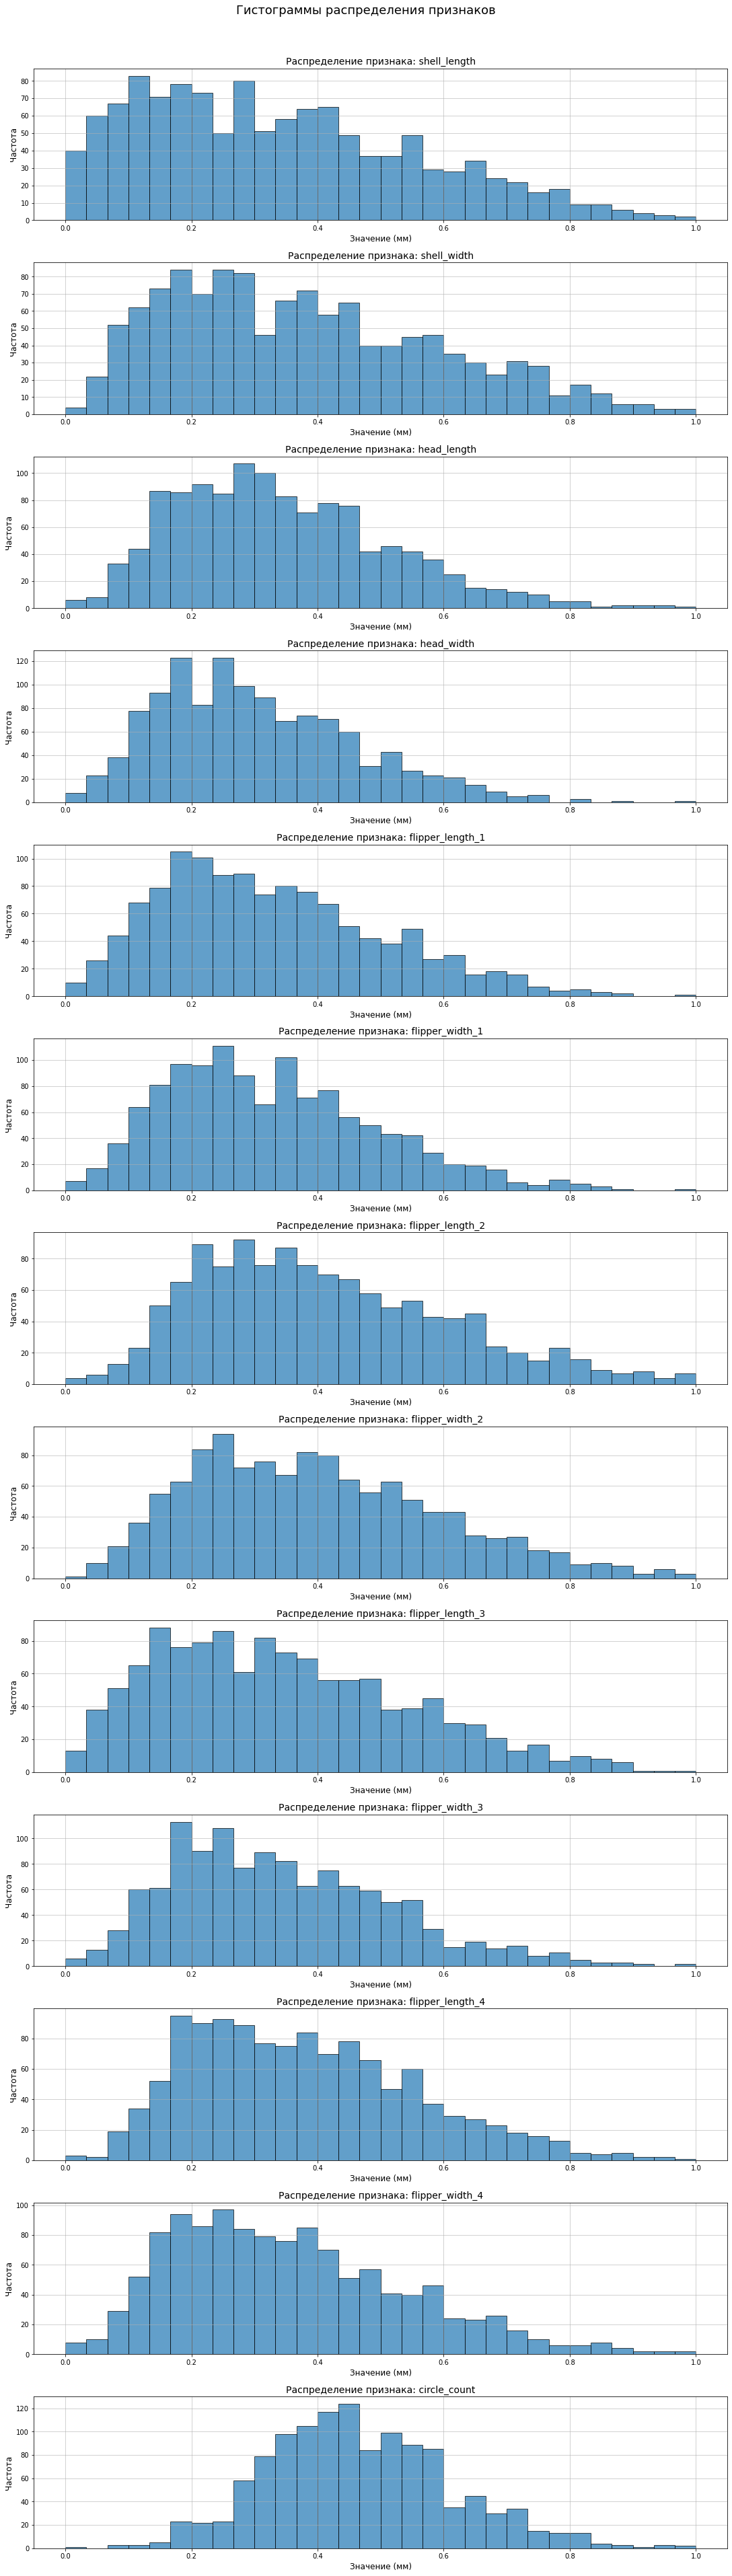

In [ ]:
display('Гистограммы X_train после min-max')
fig, axes = full_plot_bigger(X_train_minmax)
plt.show()

'Гистограммы X_train после стандартизации'

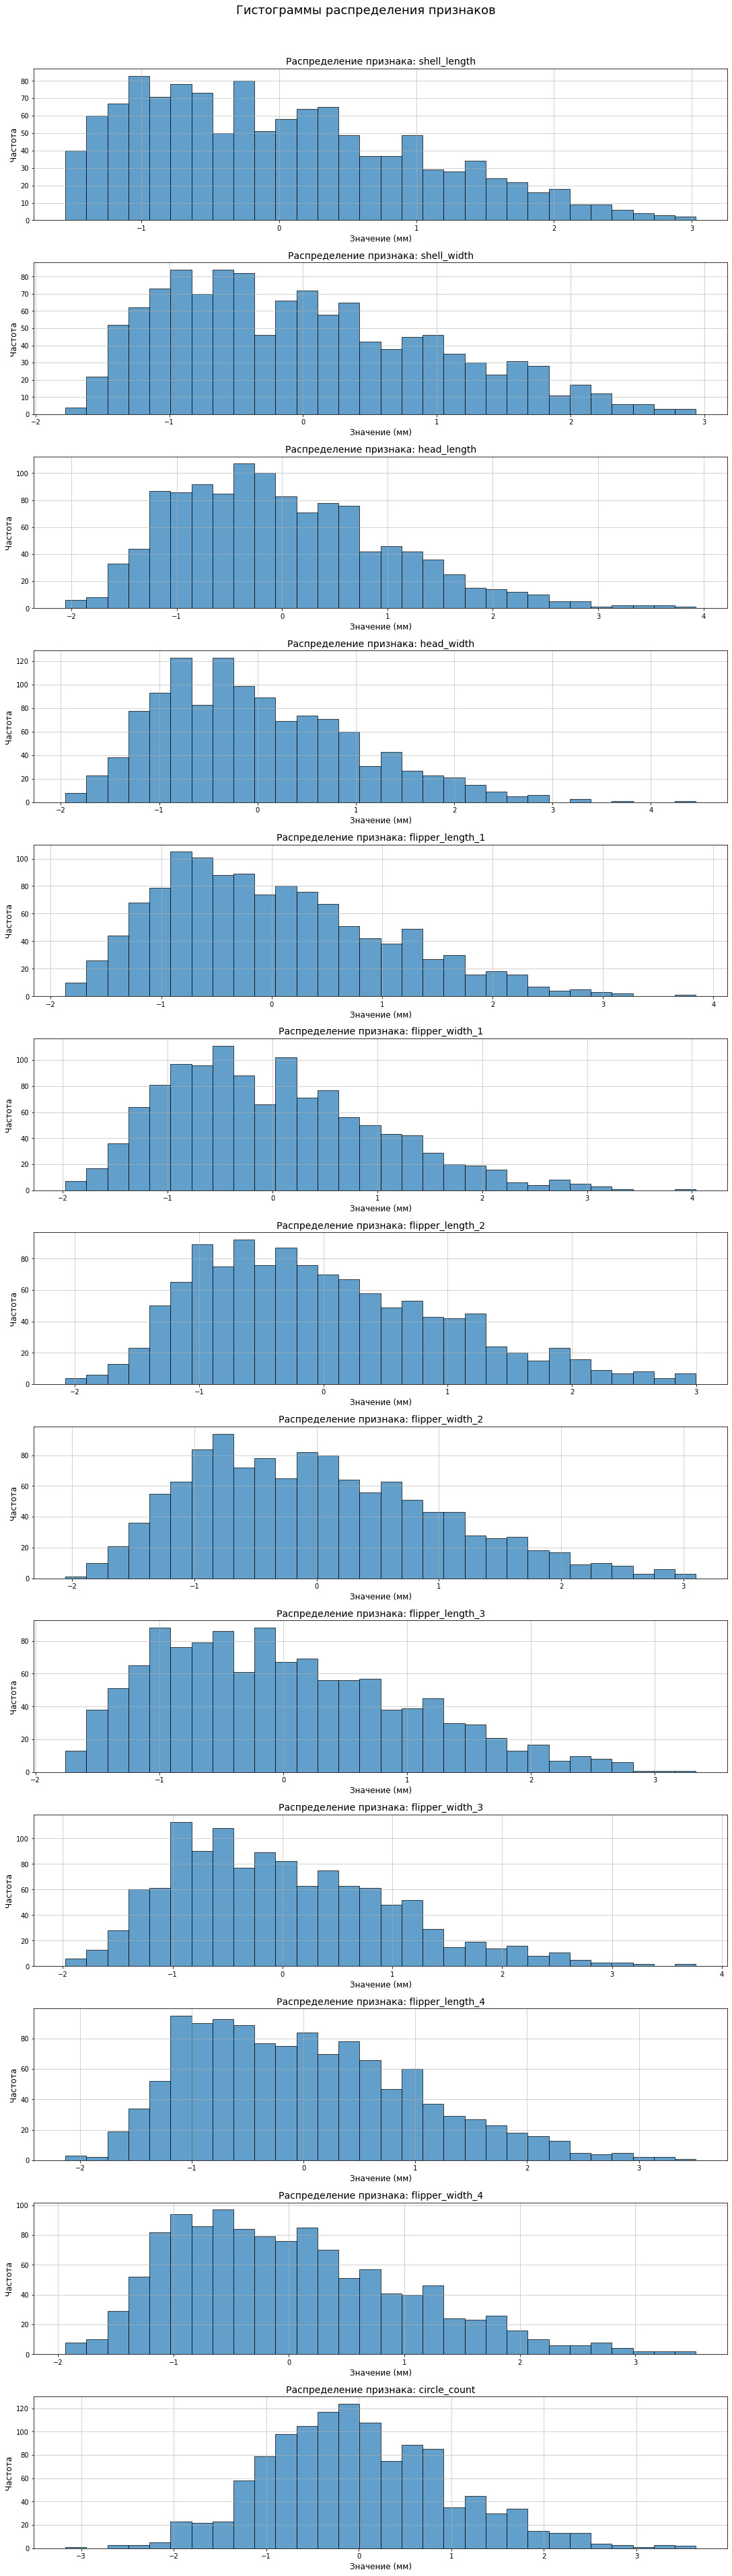

In [ ]:
display('Гистограммы X_train после стандартизации')
fig, axes = full_plot_bigger(X_train_scaled)
plt.show()

In [24]:
row_after = df_train_fill.shape[0]+df_val_fill.shape[0]+df_test_fill.shape[0]
print(f'Количество строк осталось после всех удалений: {row_after}')
print(f'Удалено выбросов:{count_row1 - row_after}')
print(f'Удалено строк:{round((count_row-row_after), 2)}')
print(f'Удалено дубликатов:{round(((count_row-row_after)*100/count_row), 2)}%')

Количество строк осталось после всех удалений: 2028
Удалено выбросов:0
Удалено строк:297
Удалено дубликатов:12.77%


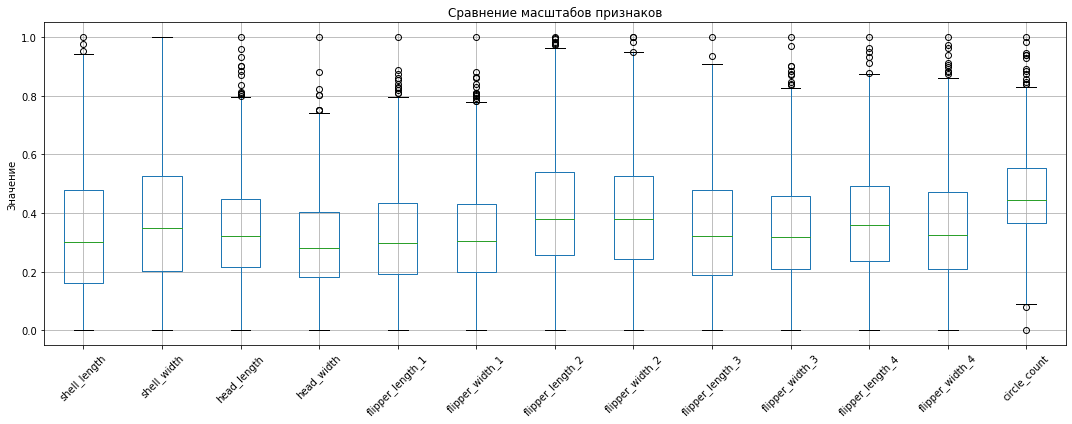

In [ ]:
# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(15, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
X_train_minmax.boxplot(column=['shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Поворот подписей по оси X
plt.xticks(rotation=45)

# Автоматическая корректировка отступов, чтобы подписи не обрезались
plt.tight_layout()

# Показываем график
plt.show() 

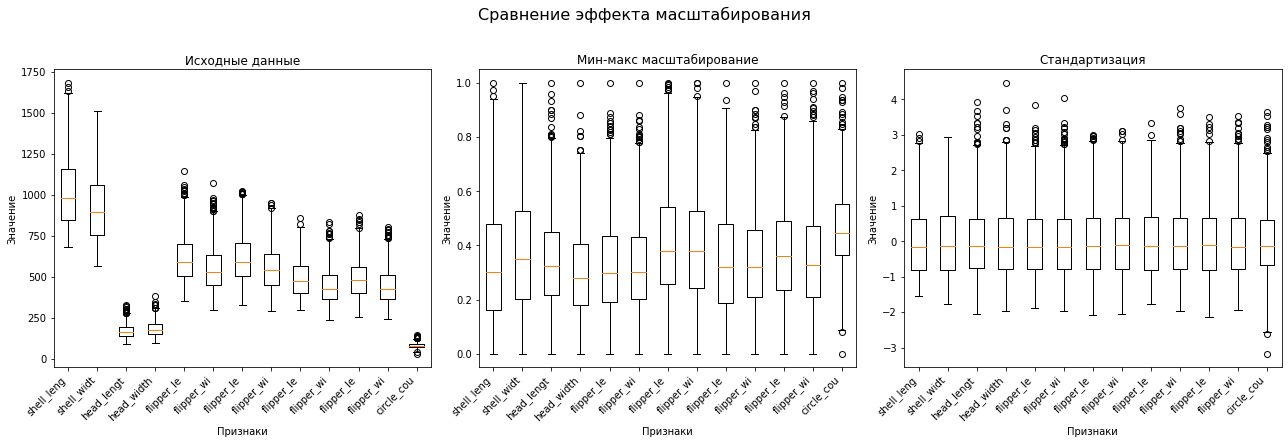

In [26]:
# Список датафреймов и их названий
dataframes = [X_train, X_train_minmax, X_train_scaled]
titles = ['Исходные данные', 'Мин-макс масштабирование', 'Стандартизация']

# Создаем фигуру с тремя subplot в одном ряду
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Список признаков для отображения
features = ['shell_length', 'shell_width', 'head_length', 'head_width', 
            'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 
            'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 
            'flipper_length_4', 'flipper_width_4', 'circle_count']

# Строим боксплоты для каждого датафрейма
for i, (df, title) in enumerate(zip(dataframes, titles)):
    axes[i].boxplot([df[col].values for col in features if col in df.columns])
    axes[i].set_title(title)
    axes[i].set_ylabel('Значение')
    axes[i].set_xlabel('Признаки')
    
    # Настройка подписей оси X (можно повернуть для читаемости)
    axes[i].set_xticks(range(1, len(features) + 1))
    axes[i].set_xticklabels([col[:10] for col in features], rotation=45, ha='right')

# Общий заголовок для всей фигуры
fig.suptitle('Сравнение эффекта масштабирования', fontsize=16, y=1.02)

# Автоматическая настройка отступов для избежания наложения
plt.tight_layout()
plt.show()

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font><br /><font color='4682B4'>

- Количество строк осталось после всех удалений: 2028
- Удалено выбросов:0
- Удалено дубликатов:297
- Удалено дубликатов:12.77%
    
- Выполнено заполнение пропусков по среднему значению групп.
- Для значения `shell_length`, `shell_width` которые выходили за допустимые пределы, по причине их домножения ранее (выбрал значение 4000) выполнил деление на 10.
    
</font></div>

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

In [27]:

# Вычисляем среднее значение целевой переменной в обучающей выборке
y_train_mean = y_train.mean()

# Создаем предсказания для всех выборок (все значения = среднее)
y_train_pred_dummy = np.full_like(y_train, y_train_mean)
y_val_pred_dummy = np.full_like(y_val, y_train_mean)
y_test_pred_dummy = np.full_like(y_test, y_train_mean)

# Функция для расчета метрик
def calculate_metrics(y_true, y_pred):
    return {
        'MAE': round(mean_absolute_error(y_true, y_pred), 4),
        'MSE': round(mean_squared_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R2': round(r2_score(y_true, y_pred), 4),
        'MAPE': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4)
    }

# Подготовка результатов
results = []

# Дамми-модель
results.append({
    'Название модели': 'Дамми-модель',
    'Датасет': 'Без масштабирования',
    **calculate_metrics(y_val, y_val_pred_dummy)
})

# LinearRegression
models = [
    ('LinearRegression', LinearRegression(), 'StandardScaler', X_train_scaled, X_val_scaled),
    ('LinearRegression', LinearRegression(), 'MinMaxScaler', X_train_minmax, X_val_minmax)
]

# Lasso с разными alpha
for alpha in [0.01, 0.1, 1.0, 10.0]:
    models.append((f'Lasso (alpha={alpha})', Lasso(alpha=alpha, random_state=42, max_iter=10000), 
                  'StandardScaler', X_train_scaled, X_val_scaled))

# Ridge с разными alpha
for alpha in [0.01, 0.1, 1.0, 10.0]:
    models.append((f'Ridge (alpha={alpha})', Ridge(alpha=alpha, random_state=42), 
                  'StandardScaler', X_train_scaled, X_val_scaled))

# SGDRegressor с разными loss
loss_functions = ['squared_loss', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']

for loss in loss_functions:
    models.append((f'SGDRegressor (loss={loss})', 
                  SGDRegressor(loss=loss, penalty='l2', alpha=0.001, max_iter=1000, random_state=42),
                  'StandardScaler', X_train_scaled, X_val_scaled))

# Обучение моделей и сбор метрик
for model_name, model, dataset_name, X_train_data, X_val_data in models:
    model.fit(X_train_data, y_train)
    y_val_pred = model.predict(X_val_data)
    
    results.append({
        'Название модели': model_name,
        'Датасет': dataset_name,
        **calculate_metrics(y_val, y_val_pred)
    })

# Создание итоговой таблицы
results_df = pd.DataFrame(results)

# Сортировка по основной метрике (MAE)
results_df_sorted = results_df.sort_values('MAE')

# Вывод результатов
print("Таблица результатов:")
print(results_df_sorted.to_string(index=False))

Таблица результатов:
                                Название модели             Датасет     MAE       MSE    RMSE      R2         MAPE
                              Lasso (alpha=1.0)      StandardScaler  3.7744   90.6799  9.5226  0.9293 1.882221e+17
               SGDRegressor (loss=squared_loss)      StandardScaler  3.8679   91.9333  9.5882  0.9283 1.897079e+17
                              Lasso (alpha=0.1)      StandardScaler  3.8862   92.4370  9.6144  0.9279 1.905191e+17
                             Lasso (alpha=0.01)      StandardScaler  3.9106   92.7635  9.6314  0.9277 1.907779e+17
                               LinearRegression      StandardScaler  3.9136   92.8026  9.6334  0.9276 1.908070e+17
                               LinearRegression        MinMaxScaler  3.9136   92.8026  9.6334  0.9276 1.908070e+17
                             Ridge (alpha=0.01)      StandardScaler  3.9136   92.8026  9.6334  0.9276 1.908065e+17
                              Ridge (alpha=0.1)      Standa

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font><br /><font color='4682B4'>

* Лучшая модель по MAE на валидационной выборке: `Lasso (alpha=1.0)`, метрики: `MAE` = 3.78, `R²` = 0.93. 

* Так как `МАЕ` был приоритетным способом оценки по заданию наболее целесообразно проверить на тестовой выборке именно ее, остальные показатели метрик для этой модели так же выше чем у других моделей.

* Все модели за исключением `SGDRegressor (loss=huber)` оказались качественнее чем `Дамми-модель`
    
</font></div>

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [ ]:
best_model = Lasso(alpha=1, random_state=42, max_iter=10000)
best_model.fit(X_train_scaled, y_train)

# Делаем предсказания на всех выборках
y_train_pred = best_model.predict(X_train_scaled)
y_val_pred = best_model.predict(X_val_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Функция для расчета всех метрик
def calculate_all_metrics(y_true, y_pred, dataset_name):
# Рассчитывает все метрики и возвращает словарь
    metrics = {
        'Датасет': dataset_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }
    return {k: round(v, 4) if isinstance(v, (int, float)) else v for k, v in metrics.items()}

# Рассчитываем метрики для всех выборок
train_metrics = calculate_all_metrics(y_train, y_train_pred, 'Train')
val_metrics = calculate_all_metrics(y_val, y_val_pred, 'Val')
test_metrics = calculate_all_metrics(y_test, y_test_pred, 'Test')

# Создаем сводную таблицу
summary_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
print("Сводная таблица метрик для модели:")
print("Модель: Lasso (alpha=1.0) на StandardScaler")
print(summary_df.to_string(index=False))

# Анализ переобучения
print("Проверка переобучения моделя:")

# Сравниваем R² между train и val
r2_diff_train_val = train_metrics['R2'] - val_metrics['R2']
r2_diff_val_test = val_metrics['R2'] - test_metrics['R2']

print(f"R² на train: {train_metrics['R2']:.4f}")
print(f"R² на val: {val_metrics['R2']:.4f}")
print(f"R² на test: {test_metrics['R2']:.4f}")
print(f"Разница R² (train - val): {r2_diff_train_val:.4f}")
print(f"Разница R² (val - test): {r2_diff_val_test:.4f}")

# Сравниваем MAE между train и val
mae_diff_train_val = train_metrics['MAE'] - val_metrics['MAE']
mae_diff_val_test = val_metrics['MAE'] - test_metrics['MAE']

print(f"MAE на train: {train_metrics['MAE']:.4f}")
print(f"MAE на val: {val_metrics['MAE']:.4f}")
print(f"MAE на test: {test_metrics['MAE']:.4f}")
print(f"Разница MAE (train - val): {mae_diff_train_val:.4f}")
print(f"Разница MAE (val - test): {mae_diff_val_test:.4f}")

Сводная таблица метрик для модели:
Модель: Lasso (alpha=1.0) на StandardScaler
Датасет    MAE     MSE   RMSE     R2         MAPE
  Train 3.7135 31.2286 5.5883 0.9740 5.330658e+16
    Val 3.7744 90.6799 9.5226 0.9293 1.882221e+17
   Test 3.6848 24.9015 4.9901 0.9812 3.909900e+00
Проверка переобучения моделя:
R² на train: 0.9740
R² на val: 0.9293
R² на test: 0.9812
Разница R² (train - val): 0.0447
Разница R² (val - test): -0.0519
MAE на train: 3.7135
MAE на val: 3.7744
MAE на test: 3.6848
Разница MAE (train - val): -0.0609
Разница MAE (val - test): 0.0896


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font><br /><font color='4682B4'>

* Признаков переобучения у модели не наблюдается разница R^2 не большая, около 0,05.

* Значение R^2 для тестовой выборки (0.98) соответствует требованию 0,97, как и МАЕ на тестовой выборке (3.68) не более 5кг.

* Значения остальных метрик так же в приемлемых значениях.

* Исходя из того что требования заказчика выполнены в полной мере будет рациональным предложить данную модель заказчику.
    
</font></div>

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [29]:
coefficients = best_model.coef_
intercept = best_model.intercept_
feature_importance_df = pd.DataFrame({
    'Признак': X_train.columns.tolist(),
    'Коэффициент': coefficients
})
feature_importance_df = feature_importance_df.sort_values('Коэффициент', ascending=False)
print(feature_importance_df)
print(f'Смещение: {intercept}')

             Признак  Коэффициент
0       shell_length    14.771391
1        shell_width     5.742461
6   flipper_length_2     1.815510
11   flipper_width_4     1.795886
4   flipper_length_1     1.766030
8   flipper_length_3     1.546441
10  flipper_length_4     1.523259
2        head_length     1.402063
9    flipper_width_3     1.310973
5    flipper_width_1     1.249570
3         head_width     0.988281
7    flipper_width_2     0.781125
12      circle_count     0.000000
Смещение: 96.30748766447368


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font><br /><font color='4682B4'>

* Наиболее значимые признаки для модели:
* shell_length    14.771391
* shell_width     5.742461

* С данными коэффициентами я могу согласиться, значимость размера панциря кажется наибольшей в сравнении с остальными признаками
    
</font></div>

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [30]:
def predict_without_scaler(features):
    features_array = np.array(features).reshape(1, -1)
# Вычисляем mean и std на X_train
    mean_train = features_array.mean()
    std_train = features_array.std()    
    
# Стандартизируем
    features_array_scaled = (X_train - mean_train) / std_train
    return best_model.predict(features_array_scaled)[0]

# Проверьте
размеры = [742,652,118,147,411,386,507,389,414,368,311,325, 66]
вес = predict_without_scaler(размеры)
print(f"Вес: {вес:.2f} кг.")

Вес: 163.91 кг.


## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font><br /><font color='4682B4'>

1. Модели:
* LinearRegression;
* Lasso (L1-регуляризация);
* Ridge (L2-регуляризация);
* SGDRegressor
2. Результаты:
* Создана функция которая используя лучшую модель предсказывает вес черепах по переданным ей признакам.
3. Рекомендации:
* Передать данные заказчику для дальнейших испытаний модели.
4. Модель и метрики:
                   Название модели             Датасет     MAE       MSE    RMSE      R2         MAPE
                   Lasso (alpha=1.0)      StandardScaler  3.7744   90.6799  9.5226  0.9293 1.882221e+17
5. Признаки:
              Признак        Коэффициент
          shell_length        14.771391
          shell_width         5.742461
          flipper_length_2    1.815510
          flipper_width_4     1.795886
          flipper_length_1    1.766030
          flipper_length_3    1.546441
          flipper_length_4    1.523259
          head_length         1.402063
          flipper_width_3     1.310973
          flipper_width_1     1.249570
          head_width          0.988281
          flipper_width_2     0.781125
          circle_count        0.000000
6. Перспективы:
- Все модели кроме последних показывали не плохие результаты
- Самые не перспективные:
- Название модели                 Датасет                MAE       MSE       RMSE      R2         MAPE
- Lasso (alpha=10.0)          StandardScaler           9.3498   184.2352   13.5733   0.8563   1.656902e+17
- Дамми-модель                Без масштабирования      29.6176  1288.1146  35.8903  -0.0046   1.068301e+17
- SGDRegressor (loss=huber)   StandardScaler           45.5378  3270.0609  57.1844  -1.5502   5.613816e+16
    
</font></div>